In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("online_retail_II.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# Cleaning Data

In [3]:
print(df.isnull().sum())

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [4]:
df = df.dropna(subset=['Customer ID'])

In [5]:
df = df[~df['Invoice'].astype(str).str.startswith('C')]

In [6]:
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# Cohort Analytics

In [7]:
df['Customer ID'] = df['Customer ID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [8]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

## BUILD COHORT TABLE

In [9]:
df['CohortMonth'] = df.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')

In [10]:
df['CohortIndex'] = (
    df['InvoiceMonth'].apply(lambda x: x.ordinal) - df['CohortMonth'].apply(lambda x: x.ordinal)
)

In [11]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,InvoiceMonth,CohortMonth,CohortIndex
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,2009-12,2009-12,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-12,2009-12,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-12,2009-12,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,2009-12,2009-12,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009-12,2009-12,0


In [12]:
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_data.columns = ['CohortMonth', 'CohortIndex', 'Customers']

In [13]:
cohort_table = cohort_data.pivot_table(
    index='CohortMonth',
    columns='CohortIndex',
    values='Customers'
)

In [14]:
print(cohort_table.head())

CohortIndex     0      1      2      3      4      5      6      7      8   \
CohortMonth                                                                  
2009-12      955.0  337.0  319.0  406.0  363.0  343.0  360.0  327.0  321.0   
2010-01      383.0   79.0  119.0  117.0  101.0  115.0   99.0   88.0  107.0   
2010-02      374.0   89.0   84.0  109.0   92.0   75.0   72.0  107.0   95.0   
2010-03      443.0   84.0  102.0  107.0  103.0   90.0  109.0  134.0  122.0   
2010-04      294.0   57.0   57.0   48.0   54.0   66.0   81.0   77.0   31.0   

CohortIndex     9      10     11     12     13     14     15     16     17  \
CohortMonth                                                                  
2009-12      346.0  403.0  473.0  359.0  270.0  233.0  289.0  251.0  289.0   
2010-01      122.0  116.0   66.0   85.0   68.0   72.0   58.0   90.0   76.0   
2010-02      103.0   43.0   47.0   57.0   65.0   46.0   75.0   60.0   61.0   
2010-03       48.0   51.0   63.0   89.0   72.0   89.0   75.0   

## RETENTION RATE TABLE

In [15]:
cohort_size = cohort_table.iloc[:, 0]

In [16]:
retention_table = cohort_table.divide(cohort_size, axis=0).round(3) * 100

In [17]:
print("\n📈 Retention rate table (%):")
print(retention_table.head())


📈 Retention rate table (%):
CohortIndex     0     1     2     3     4     5     6     7     8     9   \
CohortMonth                                                                
2009-12      100.0  35.3  33.4  42.5  38.0  35.9  37.7  34.2  33.6  36.2   
2010-01      100.0  20.6  31.1  30.5  26.4  30.0  25.8  23.0  27.9  31.9   
2010-02      100.0  23.8  22.5  29.1  24.6  20.1  19.3  28.6  25.4  27.5   
2010-03      100.0  19.0  23.0  24.2  23.3  20.3  24.6  30.2  27.5  10.8   
2010-04      100.0  19.4  19.4  16.3  18.4  22.4  27.6  26.2  10.5  10.9   

CohortIndex    10    11    12    13    14    15    16    17    18    19    20  \
CohortMonth                                                                     
2009-12      42.2  49.5  37.6  28.3  24.4  30.3  26.3  30.3  28.3  26.0  25.5   
2010-01      30.3  17.2  22.2  17.8  18.8  15.1  23.5  19.8  18.5  19.6  24.3   
2010-02      11.5  12.6  15.2  17.4  12.3  20.1  16.0  16.3  14.4  23.0  23.0   
2010-03      11.5  14.2  20.1  16

In [18]:
retention_long = (
    retention_table
    .reset_index()
    .melt(
        id_vars='CohortMonth',
        var_name='CohortIndex',
        value_name='RetentionRate'
    )
)

retention_long.to_csv("retention_long.csv", index=False)

## VISUALISASI HEATMAP

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

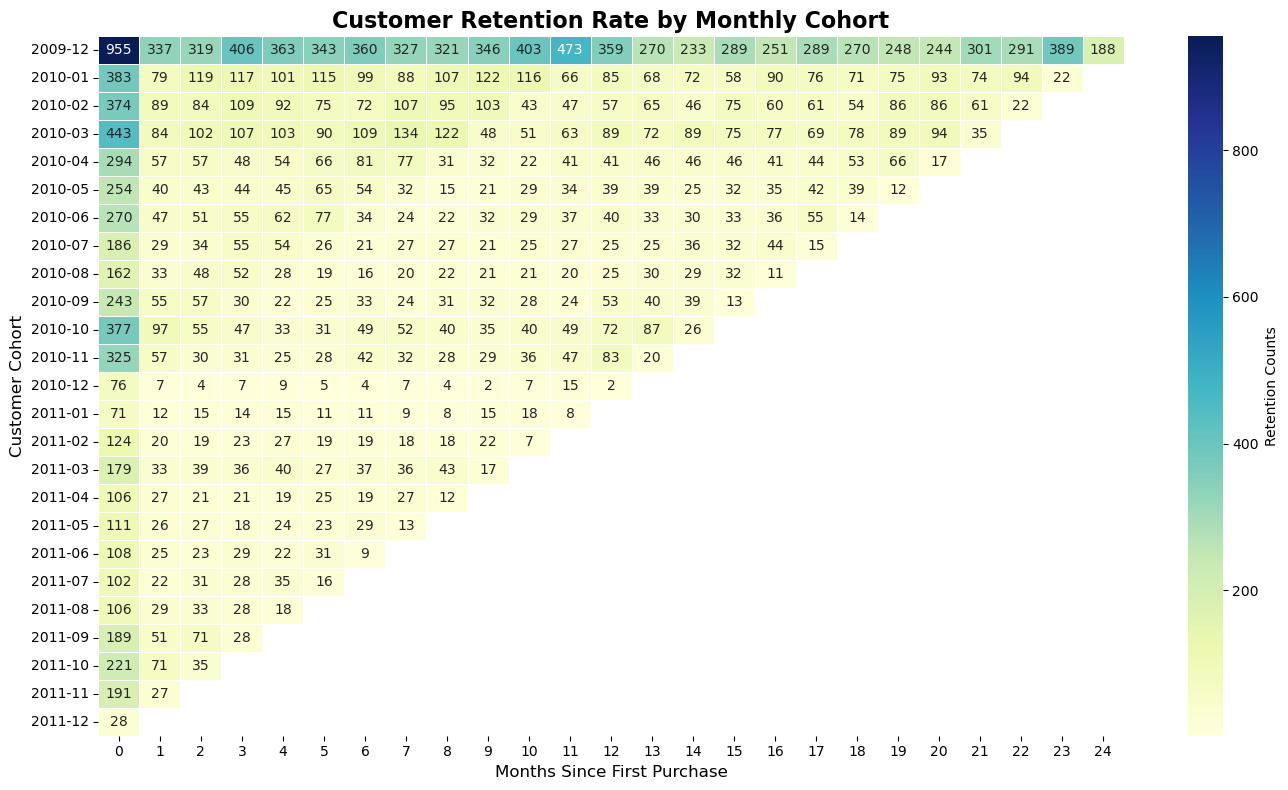

In [20]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    cohort_table,
    annot=True,          # tampilkan nilai di setiap sel
    fmt=".0f",           # 1 angka di belakang koma
    cmap="YlGnBu",       # gradasi warna
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Retention Counts"}
)

plt.title("Customer Retention Rate by Monthly Cohort", fontsize=16, fontweight="bold")
plt.xlabel("Months Since First Purchase", fontsize=12)
plt.ylabel("Customer Cohort", fontsize=12)

plt.tight_layout()
plt.show()

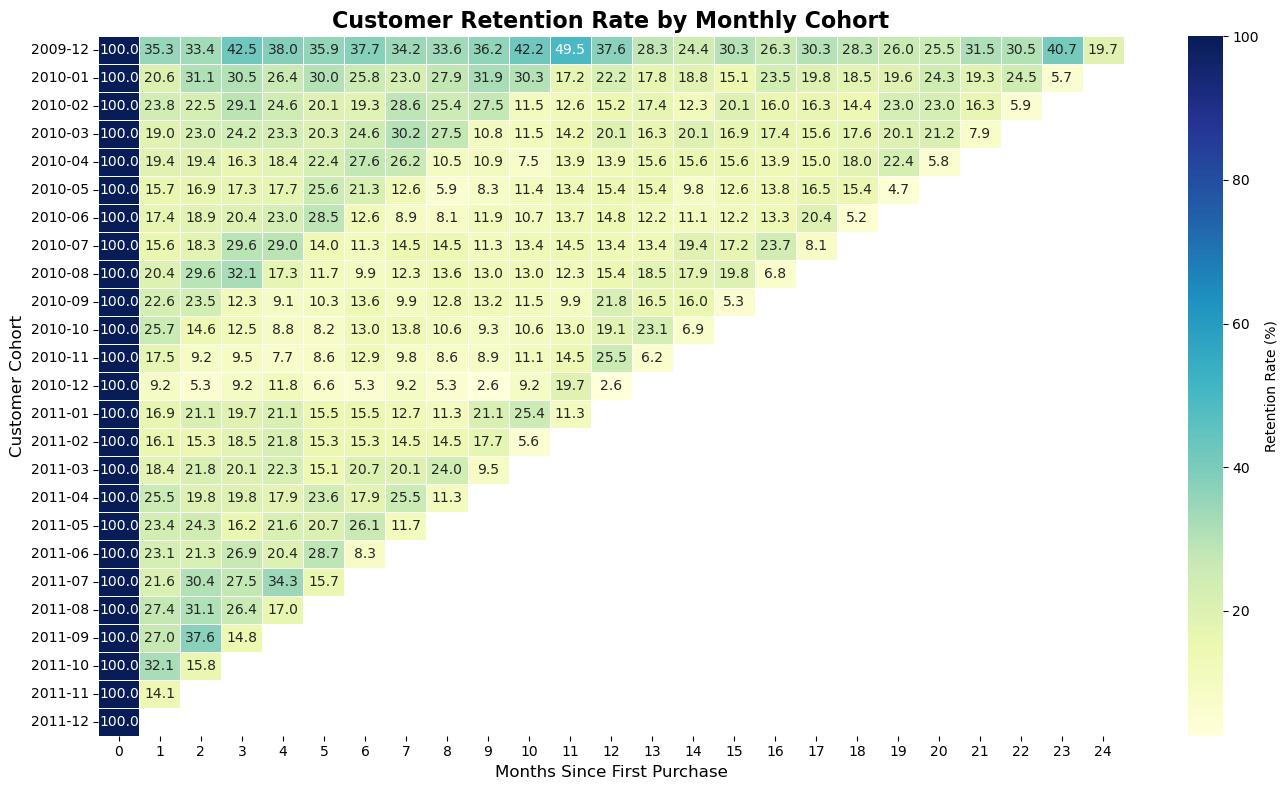

In [21]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_table,
    annot=True,          # tampilkan nilai di setiap sel
    fmt=".1f",           # 1 angka di belakang koma
    cmap="YlGnBu",       # gradasi warna
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Retention Rate (%)"}
)

plt.title("Customer Retention Rate by Monthly Cohort", fontsize=16, fontweight="bold")
plt.xlabel("Months Since First Purchase", fontsize=12)
plt.ylabel("Customer Cohort", fontsize=12)

plt.tight_layout()
plt.show()

# RFM Segmentation

In [22]:
df["TotalPrice"] = df["Quantity"] * df["Price"]

In [23]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [24]:
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "TotalPrice": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,326,12,77556.46
12347,2,8,5633.32
12348,75,5,2019.40
12349,19,4,4428.69
12350,310,1,334.40


In [25]:
rfm.describe().round(2)

,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,201.33,6.29,3018.62
std,209.34,13.01,14737.73
min,1.00,1.00,2.95
25%,26.00,1.00,348.76
50%,96.00,3.00,898.92
75%,380.00,7.00,2307.09
max,739.00,398.00,608821.65


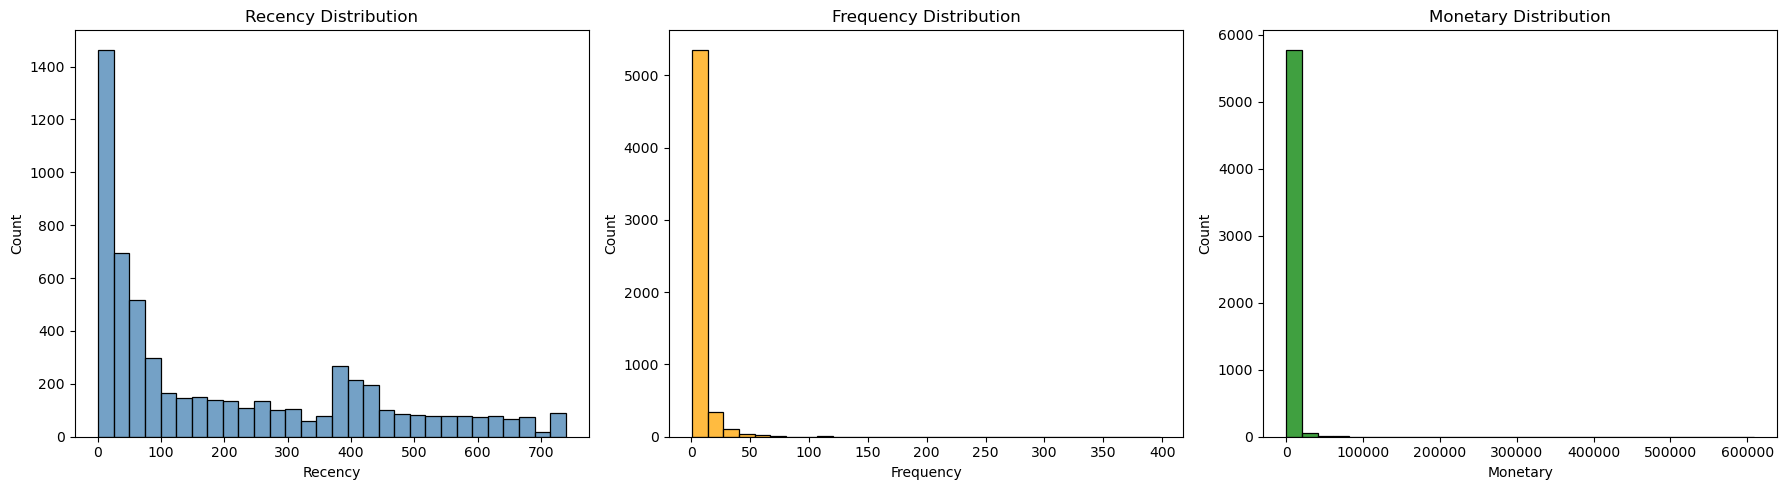

In [26]:
fig, ax = plt.subplots(1,3, figsize=(18,5))

sns.histplot(rfm["Recency"], bins=30, ax=ax[0], color="steelblue")
ax[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], bins=30, ax=ax[1], color="orange")
ax[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], bins=30, ax=ax[2], color="green")
ax[2].set_title("Monetary Distribution")

plt.tight_layout()

In [27]:
rfm["R"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm["F"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

rfm["M"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [28]:
rfm["RFM Score"] = (
    rfm["R"].astype(str)
    + rfm["F"].astype(str)
    + rfm["M"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM Score
Customer ID,,,,,,,
12346,326,12,77556.46,2,5,5,255
12347,2,8,5633.32,5,4,5,545
12348,75,5,2019.40,3,4,4,344
12349,19,4,4428.69,5,3,5,535
12350,310,1,334.40,2,1,2,212


In [29]:
def segment_customer(row):
    r = int(row["R"])
    f = int(row["F"])
    m = int(row["M"])

    # Pelanggan terbaik
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    # Sangat loyal
    elif r >= 3 and f >= 4 and m >= 3:
        return "Loyal Customers"

    # Baru bertransaksi dan berpotensi loyal
    elif r >= 4 and f >= 2 and m >= 2:
        return "Potential Loyalists"

    # Pelanggan baru
    elif r == 5 and f == 1:
        return "New Customers"

    # Baru membeli tetapi nilai transaksi masih kecil
    elif r >= 4 and f == 1:
        return "Promising"

    # Pernah sering membeli tetapi mulai tidak aktif
    elif r <= 2 and f >= 4:
        return "At Risk"

    # Dulu pelanggan terbaik tetapi sudah lama tidak membeli
    elif r == 1 and f >= 4:
        return "Can't Lose Them"

    # Hampir hilang
    elif r == 2 and f <= 2:
        return "Need Attention"

    # Sudah lama tidak membeli
    elif r == 1 and f <= 2:
        return "Lost Customers"

    # Pelanggan biasa
    elif f >= 3 and m >= 3:
        return "Regular Customers"

    # Nilai transaksi tinggi tetapi frekuensi rendah
    elif m >= 4:
        return "Big Spenders"

    # Sisanya
    else:
        return "Others"

In [30]:
rfm["Segment"] = rfm.apply(segment_customer, axis=1)

segment_count = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_count.columns = ["Segment", "Customers"]

segment_count

,Segment,Customers
0,Champions,1300
1,Lost Customers,902
2,Others,746
3,Loyal Customers,644
4,Potential Loyalists,634
5,Need Attention,621
6,Regular Customers,479
7,At Risk,353
8,Promising,114
9,New Customers,54


In [31]:
rfm.to_csv("rfm_segmentation.csv")

## VISUALISASI

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_19000\2886954562.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


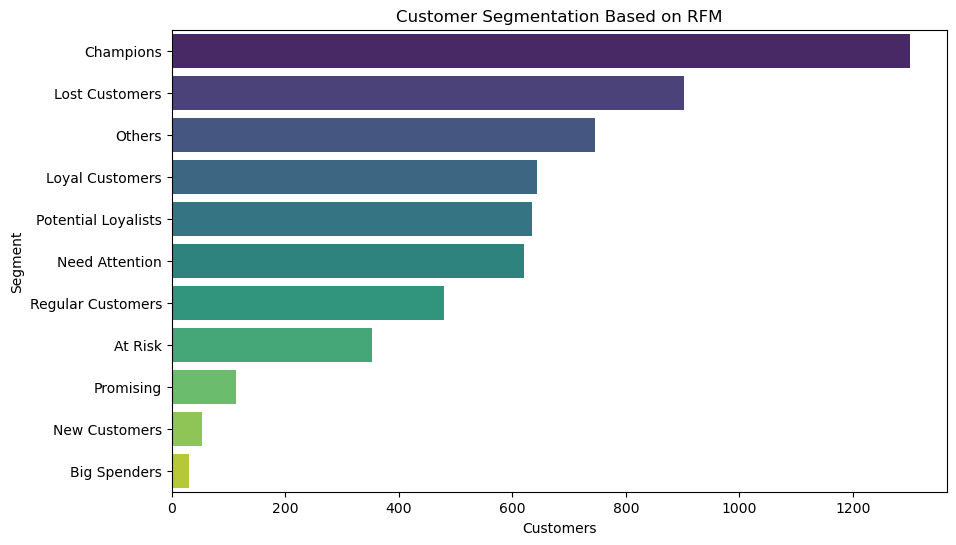

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=segment_count,
    x="Customers",
    y="Segment",
    palette="viridis"
)

plt.title("Customer Segmentation Based on RFM")

plt.show()